<a href="https://colab.research.google.com/github/Khushikumari24/student-analytics-rag/blob/main/student_intelligence_analytics_system_week_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1: Install libraries
# numpy     → the core math library (arrays, matrix ops)
# pandas    → tables of data (like Excel in Python)
# matplotlib → draw charts and graphs
# scikit-learn → machine learning tools (PCA, regression, etc.)
# scipy     → advanced statistics and probability
# ============================================================

!pip install numpy pandas matplotlib scikit-learn scipy -q  #(-q – Stands for "quiet". It stops the installer from printing too many messages, keeping the notebook clean.)

# Now we import them and give them short nicknames
import numpy as np          # np is the standard nickname everyone uses
import pandas as pd         # pd is the standard nickname for pandas
import matplotlib.pyplot as plt  # pyplot - makes plotting easy
import matplotlib.gridspec as gridspec  #-  is a part of matplotlib that helps arrange multiple charts in a grid (rows and columns).

from sklearn.preprocessing import StandardScaler  # normalizes data to same scale . mean =0 nd deviation = 1
from sklearn.decomposition import PCA             # Principal Component Analysis - compress data
from sklearn.linear_model import LinearRegression # fits a line through data
from scipy import stats                           # probability distributions ,  stats is its statistics module

# %-This line makes charts show inside the notebook (not open a new window)
%matplotlib inline #"draw plots inside the notebook line by line".

# This makes all charts look cleaner
plt.style.use('seaborn-v0_8-whitegrid') #- style name from seaborn  - whitegrid

print("✅ All libraries loaded!")

✅ All libraries loaded!


 Generate student dataset with NumPy

In [ ]:
# ============================================================
# CELL 2: Create synthetic student data
#
# WHY synthetic data? We don't have real student data, so we
# GENERATE fake-but-realistic data using NumPy's random tools.
# This teaches you how real ML projects start.
# ============================================================

# np.random.seed(42) — sets a "starting point" for random numbers
# This means EVERY time you run the cell, you get the SAME random numbers
# Without this, results would change every run — hard to debug
np.random.seed(42) #-seed = “lock the randomness” so it’s repeatable

# ── How many students ──────────────────────────────────────
N = 50  # number of students

# np.random.normal(mean, std_dev, size) generates N random numbers
# from a normal (bell curve) distribution.
# mean=65 = average score will be around 65
# std_dev=12 = most scores fall within 12 points of the average
base_scores = np.random.normal(loc=65, scale=12, size=N)

# np.clip(array, min, max) — clips all values to stay between min and max
# Without this, random scores could go below 0 or above 100
base_scores = np.clip(base_scores, 20, 98)

# ── Generate scores for 5 subjects ────────────────────────
# Each subject score = base score + some noise
# The noise makes each subject slightly different from the others
subjects = ['Math', 'Physics', 'Chemistry', 'Biology', 'CS']

# np.zeros((N, len(subjects))) creates an N×5 matrix filled with zeros
# N rows = students, 5 columns = subjects
grade_matrix = np.zeros((N, len(subjects)))

# np.random.normal(0, noise, N) adds small random variation per subject
# Think of it as: each student has a "general ability" but varies by subject
noise_levels = [8, 10, 9, 7, 11]   # each subject has different spread

for i, noise in enumerate(noise_levels):
    # i = column index (0=Math, 1=Physics, etc.)
    # base_scores + noise = overall ability + subject-specific variation
    grade_matrix[:, i] = np.clip(base_scores + np.random.normal(0, noise, N), 10, 100)

# Round all scores to 1 decimal place — np.round(array, decimals)
grade_matrix = np.round(grade_matrix, 1)

# ── Study hours ───────────────────────────────────────────
# Better students tend to study more — we model this correlation
# base_scores/10 adds the correlation (higher score → more hours)
study_hours = np.clip(
    5 + np.random.normal(0, 3, N) + base_scores / 10,
    1, 20
)
study_hours = np.round(study_hours, 1)

# ── Student names ─────────────────────────────────────────
student_names = [
    'Aarav','Priya','Rohan','Sneha','Arjun','Kavya','Vikram','Ananya',
    'Rahul','Meera','Dev','Ishaan','Nisha','Karan','Pooja','Siddharth',
    'Aisha','Nikhil','Riya','Aditya','Zara','Harsh','Diya','Kunal',
    'Simran','Yash','Tanvi','Manav','Kriti','Rajesh','Alok','Bhavna',
    'Chetan','Divya','Esha','Farhan','Geeta','Hari','Indira','Jayant',
    'Komal','Lalit','Madhu','Naresh','Omkar','Patel','Quincy','Rekha',
    'Suresh','Tara'
]

print(f"✅ Generated data for {N} students across {len(subjects)} subjects")
print(f"\nFirst 5 rows of grade matrix (rows=students, cols=subjects):")
print(grade_matrix[:5])
print(f"\nShape of grade matrix: {grade_matrix.shape}")
# Output: (50, 5) means 50 rows and 5 columns

✅ Generated data for 50 students across 5 subjects

First 5 rows of grade matrix (rows=students, cols=subjects):
[[73.6 56.8 73.2 73.5 57.1]
 [60.3 59.1 66.5 67.3 73.4]
 [67.4 69.3 66.7 80.4 96.1]
 [88.2 75.3 85.4 90.7 94.6]
 [70.4 60.6 64.8 52.5 45.5]]

Shape of grade matrix: (50, 5)


Statistics module

In [ ]:
# ============================================================
# CELL 3: STATISTICS — Mean, Median, Std Dev, Variance
#
# Statistics answers: "What does our data LOOK like overall?"
# ============================================================

print("=" * 55)
print("  MODULE 1: DESCRIPTIVE STATISTICS")
print("=" * 55)

# ── Define subject weights ────────────────────────────────
# Weights decide how much each subject contributes to the final score
# They must sum to 1.0 (100%)
weights = np.array([0.25, 0.20, 0.20, 0.15, 0.20])
# Quick check: np.sum(weights) should equal 1.0
print(f"\nWeights sum to: {np.sum(weights):.2f}  ✓" if np.isclose(np.sum(weights), 1.0) else "⚠️ Weights don't sum to 1!")

# ── Compute weighted final score ─────────────────────────
# np.dot(matrix, vector) = matrix multiplication
# For each student (row), multiply each subject score by its weight and sum
# Example: student[0] final = 72*0.25 + 68*0.20 + 71*0.20 + 65*0.15 + 70*0.20
final_scores = np.dot(grade_matrix, weights)
final_scores = np.round(final_scores, 1)

print(f"\nFirst 5 final scores (weighted): {final_scores[:5]}")

# ── Mean ──────────────────────────────────────────────────
# Mean = sum of all values ÷ count
# np.mean() does this for us
class_mean = np.mean(final_scores)
# We could also write: sum(final_scores) / len(final_scores) — same result

# ── Median ────────────────────────────────────────────────
# Median = middle value when sorted
# Less affected by extreme scores than mean
class_median = np.median(final_scores)

# ── Standard Deviation ────────────────────────────────────
# Measures how SPREAD OUT scores are around the mean
# Small std = scores clustered near mean
# Large std = scores spread far from mean
# Formula: sqrt( mean( (x - mean)^2 ) )
class_std = np.std(final_scores)

# ── Variance ──────────────────────────────────────────────
# Variance = std_dev^2  (before taking the square root)
class_var = np.var(final_scores)

# ── Percentiles ───────────────────────────────────────────
# np.percentile(data, p) tells you the value below which p% of data falls
# p25 = Q1, p50 = median = Q2, p75 = Q3
p25 = np.percentile(final_scores, 25)
p50 = np.percentile(final_scores, 50)
p75 = np.percentile(final_scores, 75)
iqr = p75 - p25  # Inter-Quartile Range = middle 50% spread

# ── Skewness ──────────────────────────────────────────────
# Skewness measures asymmetry of distribution
# 0 = perfectly symmetric, >0 = right tail, <0 = left tail
skewness = stats.skew(final_scores)

print(f"\n{'Metric':<20} {'Value':>10}")
print("-" * 32)
print(f"{'Mean':<20} {class_mean:>10.2f}")
print(f"{'Median':<20} {class_median:>10.2f}")
print(f"{'Std Deviation':<20} {class_std:>10.2f}")
print(f"{'Variance':<20} {class_var:>10.2f}")
print(f"{'Min':<20} {np.min(final_scores):>10.2f}")
print(f"{'Max':<20} {np.max(final_scores):>10.2f}")
print(f"{'Q1 (25th pct)':<20} {p25:>10.2f}")
print(f"{'Q2 (50th pct)':<20} {p50:>10.2f}")
print(f"{'Q3 (75th pct)':<20} {p75:>10.2f}")
print(f"{'IQR':<20} {iqr:>10.2f}")
print(f"{'Skewness':<20} {skewness:>10.4f}")

# ── Per-subject stats using axis parameter ────────────────
# axis=0 means "compute along rows" (gives one result per column)
# axis=1 means "compute along columns" (gives one result per row)
subject_means  = np.mean(grade_matrix, axis=0)   # average per subject
subject_stds   = np.std(grade_matrix, axis=0)    # spread per subject
student_means  = np.mean(grade_matrix, axis=1)   # each student's average

print(f"\n{'Subject':<12} {'Mean':>8} {'Std':>8}")
print("-" * 30)
for sub, m, s in zip(subjects, subject_means, subject_stds):
    print(f"{sub:<12} {m:>8.2f} {s:>8.2f}")

  MODULE 1: DESCRIPTIVE STATISTICS

Weights sum to: 1.00  ✓

First 5 final scores (weighted): [66.8 65.  75.3 86.7 59.7]

Metric                    Value
--------------------------------
Mean                      62.50
Median                    61.40
Std Deviation             12.61
Variance                 158.98
Min                       41.60
Max                       92.00
Q1 (25th pct)             52.67
Q2 (50th pct)             61.40
Q3 (75th pct)             71.85
IQR                       19.18
Skewness                 0.4526

Subject          Mean      Std
------------------------------
Math            62.44    13.71
Physics         61.84    13.83
Chemistry       63.04    14.29
Biology         63.35    15.38
CS              62.06    17.90


Linear Algebra module

In [ ]:
# ============================================================
# CELL 4: LINEAR ALGEBRA — Matrices, Vectors, Dot Product, PCA
#
# Linear algebra answers: "How do we compute with tables of numbers?"
# ============================================================

print("=" * 55)
print("  MODULE 2: LINEAR ALGEBRA")
print("=" * 55)

# ── Vectors ───────────────────────────────────────────────
# A vector is just a 1D array — a list of numbers with meaning
# Here, each student's scores across 5 subjects IS a vector
student_A = grade_matrix[0]   # first student's score vector
student_B = grade_matrix[1]   # second student's score vector

print(f"\nStudent A scores (vector): {student_A}")
print(f"Student B scores (vector): {student_B}")

# ── Vector magnitude ──────────────────────────────────────
# Magnitude = "length" of a vector
# Formula: sqrt(x1² + x2² + x3² + ...)
# np.linalg.norm() computes this
mag_A = np.linalg.norm(student_A)
mag_B = np.linalg.norm(student_B)
print(f"\n|A| magnitude = {mag_A:.2f}")
print(f"|B| magnitude = {mag_B:.2f}")

# ── Dot product ───────────────────────────────────────────
# Dot product = A[0]*B[0] + A[1]*B[1] + ...
# When both vectors are similar, dot product is large
# np.dot(a, b) computes this
dot_product = np.dot(student_A, student_B)
print(f"\nDot product A·B = {dot_product:.2f}")

# ── Cosine similarity ─────────────────────────────────────
# Measures how similar two students' performance PATTERNS are
# Range: -1 (opposite) to 1 (identical)
# Formula: (A·B) / (|A| × |B|)
cosine_sim = dot_product / (mag_A * mag_B)
print(f"Cosine similarity = {cosine_sim:.4f}")
print(f"Interpretation: {'Very similar' if cosine_sim > 0.98 else 'Similar' if cosine_sim > 0.9 else 'Different'}")

# ── Matrix multiplication ─────────────────────────────────
# grade_matrix is (50, 5)  — 50 students, 5 subjects
# weights is (5,)          — 5 weights
# np.dot(matrix, vector) → (50,) — one weighted score per student
weighted_finals = np.dot(grade_matrix, weights)
print(f"\nWeighted final scores (first 5): {weighted_finals[:5].round(1)}")

# ── Correlation matrix ────────────────────────────────────
# np.corrcoef(matrix.T) computes how correlated each pair of subjects is
# .T = transpose = flip rows and columns (needed for correct orientation)
# Result is 5×5: row i, col j = correlation between subject i and subject j
# Value close to 1 = subjects move together (if good at Math, good at Physics)
# Value close to 0 = no relationship
corr_matrix = np.corrcoef(grade_matrix.T)
print(f"\nCorrelation matrix (subjects × subjects):")
print(f"{'':>12}", end='')
for s in subjects: print(f"{s:>10}", end='')
print()
for i, sub in enumerate(subjects):
    print(f"{sub:>12}", end='')
    for j in range(len(subjects)):
        print(f"{corr_matrix[i,j]:>10.3f}", end='')
    print()

# ── PCA: Principal Component Analysis ────────────────────
# PCA finds the "most important directions" in high-dimensional data
# We have 5 dimensions (subjects) — PCA compresses to 2 for visualization
# Think of it as: finding the best "angle" to view the data from

# Step 1: StandardScaler makes all features have mean=0, std=1
# Why? Without this, subjects with larger ranges dominate PCA
scaler = StandardScaler()
scaled_grades = scaler.fit_transform(grade_matrix)
# fit_transform: fit = learn the mean/std, transform = apply scaling

# Step 2: PCA with 2 components = reduce 5D to 2D
pca = PCA(n_components=2)
pca_scores = pca.fit_transform(scaled_grades)
# pca_scores is now (50, 2) — each student is now a 2D point

# Explained variance tells us how much info we kept
ev = pca.explained_variance_ratio_
print(f"\nPCA results:")
print(f"PC1 explains {ev[0]*100:.1f}% of variance")
print(f"PC2 explains {ev[1]*100:.1f}% of variance")
print(f"Total retained: {sum(ev)*100:.1f}%")

  MODULE 2: LINEAR ALGEBRA

Student A scores (vector): [73.6 56.8 73.2 73.5 57.1]
Student B scores (vector): [60.3 59.1 66.5 67.3 73.4]

|A| magnitude = 150.55
|B| magnitude = 146.52

Dot product A·B = 21800.45
Cosine similarity = 0.9883
Interpretation: Very similar

Weighted final scores (first 5): [66.8 65.  75.3 86.7 59.7]

Correlation matrix (subjects × subjects):
                  Math   Physics Chemistry   Biology        CS
        Math     1.000     0.530     0.670     0.717     0.678
     Physics     0.530     1.000     0.608     0.700     0.547
   Chemistry     0.670     0.608     1.000     0.722     0.533
     Biology     0.717     0.700     0.722     1.000     0.753
          CS     0.678     0.547     0.533     0.753     1.000

PCA results:
PC1 explains 71.8% of variance
PC2 explains 10.4% of variance
Total retained: 82.2%


Calculus module

In [ ]:
# ============================================================
# CELL 5: CALCULUS — Derivatives, Gradient Descent
#
# Calculus answers: "How fast is something changing?"
# In ML: used to train models by minimizing error
# ============================================================

print("=" * 55)
print("  MODULE 3: CALCULUS")
print("=" * 55)

# ── Numerical derivative ──────────────────────────────────
# A derivative measures the rate of change at a point
# "How fast is this student improving?"
# Numerical formula: df/dx ≈ (f(x+h) - f(x)) / h  for small h

def learning_curve(week):
    """Models a student's score over time.
    Approaches 100 asymptotically (never quite reaches it)."""
    # This is an exponential saturation curve
    # 100 * (1 - e^(-0.45 * week))
    return 100 * (1 - np.exp(-0.45 * week))

def derivative(f, x, h=0.001):
    """Computes numerical derivative using finite difference.
    h = tiny step size. Smaller h = more accurate approximation."""
    return (f(x + h) - f(x)) / h
    # This IS the definition of a derivative — limit as h→0

# Compute scores and rates across 11 weeks
weeks = np.linspace(0, 10, 11)         # [0, 1, 2, ..., 10]
scores = learning_curve(weeks)          # score at each week
rates = [derivative(learning_curve, w) for w in weeks]  # rate at each week

print("\nWeek | Score  | Learning Rate (pts/week)")
print("-" * 40)
for w, s, r in zip(weeks, scores, rates):
    print(f"  {w:.0f}  | {s:5.1f}  | {r:6.2f}")

# ── GRADIENT DESCENT ──────────────────────────────────────
# This is HOW neural networks and ML models LEARN
# We have a "loss" (error) function. We want to find the minimum.
# Strategy: take small steps in the direction of steepest descent

# Loss function: L(w) = (w - 1)^2
# This is a simple bowl shape. Minimum is at w=1.
def loss(w):
    return (w - 1)**2

def gradient(w):
    """Derivative of loss with respect to w.
    dL/dw = 2*(w - 1)
    The gradient points UPHILL, so we go the OPPOSITE direction"""
    return 2 * (w - 1)

# Hyperparameters (settings we choose)
learning_rate = 0.1    # α — how big each step is
w = 4.0               # starting weight (far from the minimum)
n_iterations = 30     # how many steps to take

print(f"\n--- Gradient Descent (α = {learning_rate}) ---")
print(f"{'Iter':>5} | {'w':>8} | {'Loss':>10} | {'Gradient':>10}")
print("-" * 45)

history_w = [w]
history_loss = [loss(w)]

for i in range(n_iterations):
    grad = gradient(w)       # compute slope at current w
    w = w - learning_rate * grad  # take a step OPPOSITE to slope
    # w_new = w_old - α × gradient
    # Minus sign = move DOWNHILL (gradient points uphill)

    history_w.append(w)
    history_loss.append(loss(w))

    if i < 5 or i == n_iterations - 1:  # print first 5 and last
        print(f"{i+1:>5} | {w:>8.4f} | {loss(w):>10.6f} | {grad:>10.4f}")

print(f"\nFinal w = {w:.6f}  (True minimum = 1.0)")
print(f"Final loss = {loss(w):.8f}  (Perfect = 0.0)")

  MODULE 3: CALCULUS

Week | Score  | Learning Rate (pts/week)
----------------------------------------
  0  |   0.0  |  44.99
  1  |  36.2  |  28.69
  2  |  59.3  |  18.29
  3  |  74.1  |  11.66
  4  |  83.5  |   7.44
  5  |  89.5  |   4.74
  6  |  93.3  |   3.02
  7  |  95.7  |   1.93
  8  |  97.3  |   1.23
  9  |  98.3  |   0.78
  10  |  98.9  |   0.50

--- Gradient Descent (α = 0.1) ---
 Iter |        w |       Loss |   Gradient
---------------------------------------------
    1 |   3.4000 |   5.760000 |     6.0000
    2 |   2.9200 |   3.686400 |     4.8000
    3 |   2.5360 |   2.359296 |     3.8400
    4 |   2.2288 |   1.509949 |     3.0720
    5 |   1.9830 |   0.966368 |     2.4576
   30 |   1.0037 |   0.000014 |     0.0093

Final w = 1.003714  (True minimum = 1.0)
Final loss = 0.00001379  (Perfect = 0.0)


 Probability module

In [ ]:
# ============================================================
# CELL 6: PROBABILITY — Normal Distribution, Bayes, Monte Carlo
#
# Probability answers: "How LIKELY is something to happen?"
# ============================================================

print("=" * 55)
print("  MODULE 4: PROBABILITY")
print("=" * 55)

# ── Normal (Gaussian) Distribution ───────────────────────
# Most real measurements follow a bell curve
# Defined by: mean μ (center) and std σ (width)
# scipy.stats.norm gives us all the tools

mu    = np.mean(final_scores)   # use our actual class mean
sigma = np.std(final_scores)    # use our actual class std

print(f"\nFitting Normal distribution to class scores:")
print(f"μ (mean) = {mu:.2f},  σ (std dev) = {sigma:.2f}")

# Probability density function (PDF) — height of bell curve at x
x_range = np.linspace(10, 100, 200)
pdf_values = stats.norm.pdf(x_range, mu, sigma)
# stats.norm.pdf(x, mu, sigma) = height of bell curve at x

# Cumulative distribution function (CDF) — P(score ≤ x)
# How likely is a student to score BELOW 50?
p_fail = stats.norm.cdf(50, mu, sigma)
# cdf gives probability of being BELOW a value
p_pass = 1 - p_fail   # probability of being AT or ABOVE 50
print(f"\nP(score < 50)  = {p_fail:.3f}  ({p_fail*100:.1f}%)")
print(f"P(score ≥ 50)  = {p_pass:.3f}  ({p_pass*100:.1f}%)")

# z-score: how many std devs away from mean is a score?
# z = (x - μ) / σ
top_student_score = np.max(final_scores)
z_score = (top_student_score - mu) / sigma
print(f"\nTop score: {top_student_score:.1f}")
print(f"z-score = ({top_student_score:.1f} - {mu:.2f}) / {sigma:.2f} = {z_score:.2f}")
print(f"This student is {z_score:.2f} standard deviations above average")

# ── Bayes' Theorem ────────────────────────────────────────
# Bayes updates our belief when we get new evidence
# P(Pass | HW submitted) = P(HW | Pass) × P(Pass) / P(HW)
# Prior      = our initial belief (before evidence)
# Likelihood = how probable the evidence is IF hypothesis is true
# Posterior  = updated belief AFTER seeing evidence

p_pass_prior    = 0.60   # 60% of students pass historically
p_hw_given_pass = 0.85   # 85% of passing students submit homework
p_hw_given_fail = 0.35   # 35% of failing students submit homework

# Total probability of HW being submitted (Law of Total Probability):
# P(HW) = P(HW|Pass)*P(Pass) + P(HW|Fail)*P(Fail)
p_hw = p_hw_given_pass * p_pass_prior + p_hw_given_fail * (1 - p_pass_prior)

# Bayes formula:
posterior = (p_hw_given_pass * p_pass_prior) / p_hw

print(f"\n--- Bayes' Theorem ---")
print(f"Prior P(Pass)          = {p_pass_prior:.2f}")
print(f"P(HW submitted | Pass) = {p_hw_given_pass:.2f}")
print(f"P(HW submitted | Fail) = {p_hw_given_fail:.2f}")
print(f"P(HW submitted)        = {p_hw:.3f}")
print(f"Posterior P(Pass | HW) = {posterior:.3f}  ({posterior*100:.1f}%)")
print(f"Evidence raised pass probability from {p_pass_prior*100:.0f}% to {posterior*100:.1f}%!")

# ── Monte Carlo Simulation ────────────────────────────────
# Instead of solving mathematically, we SIMULATE millions of random outcomes
# and COUNT how many match our condition
# Think of it as: rolling dice 100,000 times to estimate probability

n_simulations = 50_000   # simulate 50,000 students
# np.random.normal(mean, std, n) draws n random samples
simulated_scores = np.random.normal(mu, sigma, n_simulations)
simulated_scores = np.clip(simulated_scores, 0, 100)

# Count passing students and divide by total = estimated probability
mc_pass_rate = np.mean(simulated_scores >= 50)
# np.mean on a boolean array = fraction of True values = probability

print(f"\n--- Monte Carlo Simulation ---")
print(f"Simulated {n_simulations:,} students")
print(f"Monte Carlo pass rate  = {mc_pass_rate:.4f}  ({mc_pass_rate*100:.2f}%)")
print(f"Analytical answer      = {p_pass:.4f}  ({p_pass*100:.2f}%)")
print(f"Error: {abs(mc_pass_rate - p_pass)*100:.2f}% — smaller with more simulations!")

  MODULE 4: PROBABILITY

Fitting Normal distribution to class scores:
μ (mean) = 62.50,  σ (std dev) = 12.61

P(score < 50)  = 0.161  (16.1%)
P(score ≥ 50)  = 0.839  (83.9%)

Top score: 92.0
z-score = (92.0 - 62.50) / 12.61 = 2.34
This student is 2.34 standard deviations above average

--- Bayes' Theorem ---
Prior P(Pass)          = 0.60
P(HW submitted | Pass) = 0.85
P(HW submitted | Fail) = 0.35
P(HW submitted)        = 0.650
Posterior P(Pass | HW) = 0.785  (78.5%)
Evidence raised pass probability from 60% to 78.5%!

--- Monte Carlo Simulation ---
Simulated 50,000 students
Monte Carlo pass rate  = 0.8398  (83.98%)
Analytical answer      = 0.8393  (83.93%)
Error: 0.05% — smaller with more simulations!


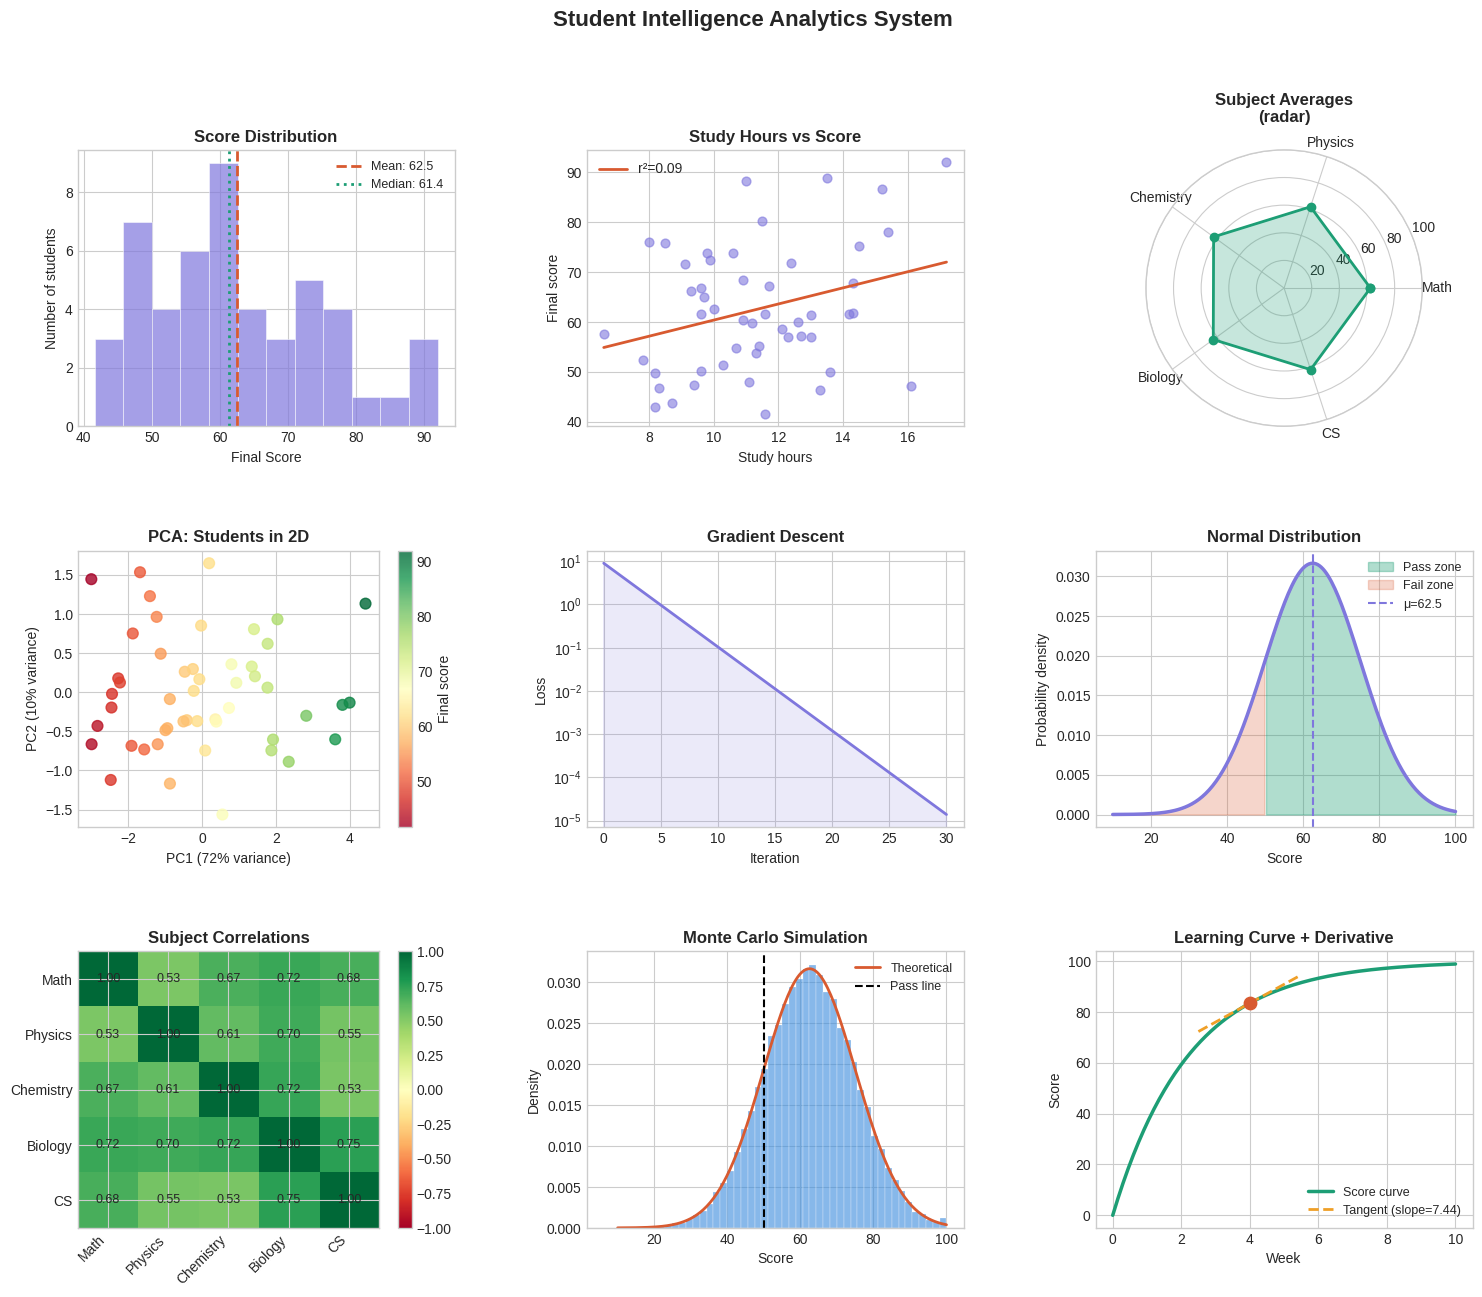

✅ Dashboard saved to /content/student_analytics_dashboard.png


In [ ]:
# ============================================================
# CELL 7: Complete visualization dashboard
# ============================================================

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Student Intelligence Analytics System', fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Plot 1: Score distribution histogram ─────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(final_scores, bins=12, color='#7F77DD', alpha=0.7, edgecolor='white', linewidth=0.5)
ax1.axvline(class_mean, color='#D85A30', linewidth=2, linestyle='--', label=f'Mean: {class_mean:.1f}')
ax1.axvline(class_median, color='#1D9E75', linewidth=2, linestyle=':', label=f'Median: {class_median:.1f}')
ax1.set_title('Score Distribution', fontweight='bold')
ax1.set_xlabel('Final Score'); ax1.set_ylabel('Number of students')
ax1.legend(fontsize=9)

# ── Plot 2: Study hours vs score scatter + regression ─────
ax2 = fig.add_subplot(gs[0, 1])
# np.argsort returns indices that would sort the array (for clean regression line)
sort_idx = np.argsort(study_hours)
reg = LinearRegression().fit(study_hours.reshape(-1,1), final_scores)
# reshape(-1,1) turns 1D array to 2D column (sklearn requires 2D input)
pred = reg.predict(study_hours[sort_idx].reshape(-1,1))
ax2.scatter(study_hours, final_scores, alpha=0.6, color='#7F77DD', s=40)
ax2.plot(study_hours[sort_idx], pred, color='#D85A30', linewidth=2, label=f'r²={reg.score(study_hours.reshape(-1,1), final_scores):.2f}')
ax2.set_title('Study Hours vs Score', fontweight='bold')
ax2.set_xlabel('Study hours'); ax2.set_ylabel('Final score')
ax2.legend()

# ── Plot 3: Subject radar chart ───────────────────────────
ax3 = fig.add_subplot(gs[0, 2], polar=True)
# Polar = circular axes. We need angles for each subject.
angles = np.linspace(0, 2*np.pi, len(subjects), endpoint=False)
# Append first value to close the polygon
vals = np.append(subject_means, subject_means[0])
angs = np.append(angles, angles[0])
ax3.plot(angs, vals, 'o-', color='#1D9E75', linewidth=2)
ax3.fill(angs, vals, alpha=0.25, color='#1D9E75')
ax3.set_xticks(angles); ax3.set_xticklabels(subjects)
ax3.set_ylim(0, 100)
ax3.set_title('Subject Averages\n(radar)', fontweight='bold', pad=20)

# ── Plot 4: PCA scatter ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
scatter = ax4.scatter(pca_scores[:, 0], pca_scores[:, 1],
                      c=final_scores, cmap='RdYlGn', s=60, alpha=0.8)
plt.colorbar(scatter, ax=ax4, label='Final score')
ax4.set_title('PCA: Students in 2D', fontweight='bold')
ax4.set_xlabel(f'PC1 ({ev[0]*100:.0f}% variance)')
ax4.set_ylabel(f'PC2 ({ev[1]*100:.0f}% variance)')

# ── Plot 5: Gradient descent loss curve ───────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(range(len(history_loss)), history_loss, color='#7F77DD', linewidth=2)
ax5.fill_between(range(len(history_loss)), history_loss, alpha=0.15, color='#7F77DD')
ax5.set_title('Gradient Descent', fontweight='bold')
ax5.set_xlabel('Iteration'); ax5.set_ylabel('Loss')
ax5.set_yscale('log')  # log scale shows convergence better

# ── Plot 6: Normal distribution ───────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(x_range, pdf_values, color='#7F77DD', linewidth=2.5)
ax6.fill_between(x_range, pdf_values, where=(x_range >= 50), alpha=0.35, color='#1D9E75', label='Pass zone')
ax6.fill_between(x_range, pdf_values, where=(x_range < 50), alpha=0.25, color='#D85A30', label='Fail zone')
ax6.axvline(mu, color='#7F77DD', linestyle='--', linewidth=1.5, label=f'μ={mu:.1f}')
ax6.set_title('Normal Distribution', fontweight='bold')
ax6.set_xlabel('Score'); ax6.set_ylabel('Probability density')
ax6.legend(fontsize=9)

# ── Plot 7: Correlation heatmap ───────────────────────────
ax7 = fig.add_subplot(gs[2, 0])
im = ax7.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax7.set_xticks(range(len(subjects))); ax7.set_yticks(range(len(subjects)))
ax7.set_xticklabels(subjects, rotation=45, ha='right')
ax7.set_yticklabels(subjects)
for i in range(len(subjects)):
    for j in range(len(subjects)):
        ax7.text(j, i, f'{corr_matrix[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax7)
ax7.set_title('Subject Correlations', fontweight='bold')

# ── Plot 8: Monte Carlo histogram ─────────────────────────
ax8 = fig.add_subplot(gs[2, 1])
ax8.hist(simulated_scores, bins=50, color='#378ADD', alpha=0.6, edgecolor='white', linewidth=0.3, density=True)
ax8.plot(x_range, pdf_values, color='#D85A30', linewidth=2, label='Theoretical')
ax8.axvline(50, color='black', linestyle='--', linewidth=1.5, label='Pass line')
ax8.set_title('Monte Carlo Simulation', fontweight='bold')
ax8.set_xlabel('Score'); ax8.set_ylabel('Density')
ax8.legend(fontsize=9)

# ── Plot 9: Derivative / tangent line ─────────────────────
ax9 = fig.add_subplot(gs[2, 2])
w_plot = np.linspace(0, 10, 200)
score_curve = learning_curve(w_plot)
ax9.plot(w_plot, score_curve, color='#1D9E75', linewidth=2.5, label='Score curve')
# Draw tangent line at week 4
t_week = 4; slope = derivative(learning_curve, t_week)
tangent_x = np.array([t_week-1.5, t_week+1.5])
tangent_y = learning_curve(t_week) + slope * (tangent_x - t_week)
ax9.plot(tangent_x, tangent_y, color='#EF9F27', linewidth=2, linestyle='--', label=f'Tangent (slope={slope:.2f})')
ax9.scatter([t_week], [learning_curve(t_week)], color='#D85A30', s=80, zorder=5)
ax9.set_title('Learning Curve + Derivative', fontweight='bold')
ax9.set_xlabel('Week'); ax9.set_ylabel('Score')
ax9.legend(fontsize=9)

plt.savefig('/content/student_analytics_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved to /content/student_analytics_dashboard.png")